# 2. Which pair should be measured?

Notebook 1 ranked residues: it said where a dye can go. An experiment does not
measure a residue, it measures a *pair*, and the two questions have different
answers. A pair is worth the mutation when three things hold at once:

1. both sites can carry a dye -- that is the label score, from notebook 1;
2. the dye-dye distance sits where FRET responds to it, near $R_0$;
3. and, if the point is a conformational change, that distance **changes**
   between the two states.

The Labelizer has a score for each of the last two. `labelizer_fret_pair_scores`
answers the one-state question,

$$ \text{score} = \text{jls}\cdot\bigl(1 - 2\,|E - \tfrac12|\bigr), $$

which peaks where the transfer efficiency is one half, and
`labelizer_pair_scores_two_states` answers the two-state question,

$$ \text{score} = \text{jls}\cdot |E_1 - E_2|, $$

which peaks where the efficiency moves most. `jls` is the *joined label score*
of the sites -- the labelability of notebook 1, carried into the pair.

The molecule is hGBP1, and the two states are the two ends of the recorded
stalk transition animated in notebook 1: frame 0 and frame 57. As there, the
chain labels `A` and `B` are residue ranges 1-151 and 152-570 of one
polypeptide, not two protomers, so every pair below is an intramolecular
distance.

This notebook runs both screens, compares them, and then checks the winners
against accessible volumes built independently of the screen. The comparison
does not come out clean, and the places where it does not are the useful part.

In [1]:
%matplotlib inline
import contextlib, os, pathlib, sys, tempfile, time

import numpy as np
import matplotlib.pyplot as plt

import IMP.bff as bff

# workshop.py sits beside this notebook; nbconvert may be run from anywhere.
for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
    if (candidate / "workshop.py").exists():
        sys.path.insert(0, str(candidate)); break
    if (candidate / "doc" / "workshop" / "workshop.py").exists():
        sys.path.insert(0, str(candidate / "doc" / "workshop")); break
import workshop as ws


@contextlib.contextmanager
def quiet():
    # Building one accessible volume prints a PDB-read banner, and this
    # notebook builds a few hundred. The banners are written to the process's
    # file descriptors, not to sys.stdout, so they are closed off there.
    saved, devnull = [os.dup(1), os.dup(2)], os.open(os.devnull, os.O_WRONLY)
    sys.stdout.flush(); sys.stderr.flush()
    os.dup2(devnull, 1); os.dup2(devnull, 2)
    try:
        yield
    finally:
        sys.stdout.flush(); sys.stderr.flush()
        os.dup2(saved[0], 1); os.dup2(saved[1], 2)
        for fd in (devnull, *saved):
            os.close(fd)


print("build:", bff.get_build(), "| version:", bff.get_module_version())
ENDS = {"start": 0, "end": ws.hgbp1_n_frames() - 1}
paths = {state: str(ws.hgbp1_state(frame)) for state, frame in ENDS.items()}
for state, frame in ENDS.items():
    print(f"{state:5s} frame {frame:2d} of the recorded transition  {paths[state]}")

build: imp | version: ab5de21
start frame  0 of the recorded transition  /Users/tpeulen/dev/imp.bff/doc/workshop/_data/hGBP1_frame000.pdb
end   frame 57 of the recorded transition  /Users/tpeulen/dev/imp.bff/doc/workshop/_data/hGBP1_frame057.pdb


## The label scores again, in two lines

Notebook 1 established the model this workshop uses: the published one,
conservation term on, on the ConSurf grades `ws.hgbp1_consurf_grades()` fetches
and caches in `_data/`. Nothing here re-derives that; the scores are simply
recomputed.

`labelizer_combined_by_key` returns the combination keyed the way the pair
functions want it -- `"B199"`, chain and residue number in one string.

In [2]:
model = bff.labelizer_model_paper()        # the full published model, as notebook 1
grades = str(ws.hgbp1_consurf_grades())
print("model:", [(p.tag, p.weight) for p in model])

with quiet():
    rows = {state: bff.labelizer_score_structure(path, model, bff.LabelizerOptions(), grades)
            for state, path in paths.items()}
label_scores = {state: bff.labelizer_combined_by_key(scored) for state, scored in rows.items()}
by_site = {state: dict(table) for state, table in label_scores.items()}   # a plain dict to look in

THRESHOLD = 1.5            # the shortlist threshold of notebook 1
for state, table in label_scores.items():
    values = np.array(list(table.values()))
    print(f"{state:5s} {len(values):5d} scored, {values.min():.2f}-{values.max():.2f}, "
          f"{(values >= THRESHOLD).sum():4d} at or above {THRESHOLD}")

model: [('cs', 1), ('se', 1), ('tp', 0), ('cr', 1), ('ss', 1), ('ce', 0)]
start   570 scored, 0.00-1.97,   69 at or above 1.5
end     570 scored, 0.00-1.97,   77 at or above 1.5


## The dye, and what the screen is allowed to cost

The pair functions carry their own dye geometry, and its defaults are not this
workshop's dye: `LabelizerFRETOptions` starts at a 9 A probe radius, where
`workshop.DYES["Alexa488"]` uses 3.5 A. A 9 A sphere does not fit beside a
tight site, so with the defaults a number of sites come back with an empty
volume. The options below are set to the workshop's Alexa488 so that the screen
and the cross-check later on are talking about the same molecule.

`label_score_threshold` is the other lever. Its default of 0.5 leaves 529 of
hGBP1's 570 residues in play and therefore 139 656 pairs; the threshold from
notebook 1 leaves 69 sites in the start state, which is 2346 pairs, and those
are the sites anyone would actually mutate.

In [3]:
def fret_options(**overrides):
    # The workshop's Alexa488 geometry, in the fields the pair screen reads.
    dye = ws.DYES["Alexa488"]
    options = bff.LabelizerFRETOptions()
    options.forster_radius = ws.R0
    options.label_score_threshold = THRESHOLD
    options.linker_length = dye["linker_length"]
    options.linker_width = dye["linker_width"]
    options.r1, options.r2, options.r3 = dye["av1_radius"], 0.0, 0.0
    options.n_refine = 0
    for name, value in overrides.items():
        setattr(options, name, value)
    return options


def name(p):
    return f"{p.asym_id_1}{p.seq_id_1}-{p.asym_id_2}{p.seq_id_2}"


def key(p):
    return (p.asym_id_1, p.seq_id_1, p.asym_id_2, p.seq_id_2)


base = fret_options()
print(f"R0 = {base.forster_radius:.0f} A, linker {base.linker_length:.0f}/"
      f"{base.linker_width:.1f} A, probe radius {base.r1:.1f} A, "
      f"grid {base.grid_resolution:.1f} A")
print(f"distance reported: {base.distance_type}   "
      f"(Rmp <= RDAMeanE <= <R_DA>; RDAMeanE is what a FRET experiment measures)")

for threshold in (0.5, 1.0, THRESHOLD):
    n = int((np.array(list(label_scores["start"].values())) >= threshold).sum())
    print(f"threshold {threshold:.1f}: {n:4d} sites, {n * (n - 1) // 2:7d} pairs")

R0 = 52 A, linker 20/4.5 A, probe radius 3.5 A, grid 1.5 A
distance reported: RDAMeanE   (Rmp <= RDAMeanE <= <R_DA>; RDAMeanE is what a FRET experiment measures)
threshold 0.5:  529 sites,  139656 pairs
threshold 1.0:  309 sites,   47586 pairs
threshold 1.5:   69 sites,    2346 pairs


## One state: where is the efficiency one half?

The screen places a dye at every site above the threshold, forms every pair,
and scores it. With `n_refine = 0` the dye is the reference's analytic **alpha
cone**: a point on the outward normal from the C-beta, pushed out by a fraction
of the linker length that shrinks as the site gets buried. One neighbour search
per site, so the whole screen is instant.

In [4]:
t0 = time.time()
with quiet():
    cone = list(bff.labelizer_fret_pair_scores(paths["start"], label_scores["start"],
                                               fret_options()))
n_sites = int(round((1 + (1 + 8 * len(cone)) ** 0.5) / 2))
print(f"{len(cone)} pairs from {n_sites} labelable sites, in {time.time() - t0:.1f} s")

print(f"\n{'pair':<14} {'score':>7} {'jls':>6} {'d / A':>7} {'E':>6}")
for p in cone[:10]:
    print(f"{name(p):<14} {p.value:7.4f} {p.joined_label_score:6.3f} {p.distance:7.1f} "
          f"{ws.efficiency(p.distance):6.3f}")

# The formula, checked once on the top row.
p = cone[0]
e = ws.efficiency(p.distance)
print(f"\njls * (1 - 2|E - 0.5|) = {p.joined_label_score:.4f} * "
      f"{1 - 2 * abs(e - 0.5):.4f} = {p.joined_label_score * (1 - 2 * abs(e - 0.5)):.4f}"
      f"   reported {p.value:.4f}")

2346 pairs from 69 labelable sites, in 0.0 s

pair             score    jls   d / A      E
B199-B270       1.7884  1.829    52.4  0.489
A11-B199        1.7555  1.829    51.3  0.520
A12-A81         1.7550  1.782    51.7  0.508
B199-B263       1.7302  1.738    52.1  0.498
A81-B567        1.7275  1.755    51.7  0.508
A12-B270        1.7274  1.770    51.6  0.512
A12-B254        1.7205  1.740    51.8  0.505
A12-B258        1.7081  1.730    52.2  0.494
A2-B181         1.6998  1.800    53.0  0.472
A11-B358        1.6921  1.731    52.4  0.489

jls * (1 - 2|E - 0.5|) = 1.8292 * 0.9777 = 1.7884   reported 1.7884


### The second tier: rebuild the best few with a real volume

The cone is a point. A dye is a cloud, and the distance between two clouds is
not the distance between their two mean positions -- the screen reports
`RDAMeanE`, the distance that reproduces the mean transfer efficiency, which is
what an experiment measures. `n_refine` takes the top of the cone's list and
recomputes exactly those pairs with accessible volumes, rebuilding only the
sites those pairs use.

Because the score peaks sharply at $R = R_0$, a couple of Angstrom moves a pair
a long way down the list. That is the whole reason the second tier exists.

In [5]:
N_REFINE = 150
t0 = time.time()
with quiet():
    refined = list(bff.labelizer_fret_pair_scores(paths["start"], label_scores["start"],
                                                  fret_options(n_refine=N_REFINE)))
print(f"{N_REFINE} pairs rebuilt with accessible volumes in {time.time() - t0:.1f} s")

cone_rank = {key(p): i for i, p in enumerate(cone)}
cone_distance = {key(p): p.distance for p in cone}
cone_value = {key(p): p.value for p in cone}
new_rank = {key(p): i for i, p in enumerate(refined)}
av_rows = [p for p in refined if p.probe_model == bff.PROBE_MODEL_ACCESSIBLE_VOLUME]
print(f"rows carrying probe_model == PROBE_MODEL_ACCESSIBLE_VOLUME: {len(av_rows)}")

print(f"\nthe cone's ten best, after the rebuild")
print(f"{'pair':<14} {'d cone':>7} {'d AV':>7} {'change':>7} {'s cone':>7} {'s AV':>7} {'rank':>12}")
for p in cone[:10]:
    k = key(p)
    q = refined[new_rank[k]]
    print(f"{name(p):<14} {p.distance:7.1f} {q.distance:7.1f} {q.distance - p.distance:+7.1f} "
          f"{p.value:7.4f} {q.value:7.4f} {cone_rank[k] + 1:>5} ->{new_rank[k] + 1:>5}")

150 pairs rebuilt with accessible volumes in 2.1 s
rows carrying probe_model == PROBE_MODEL_ACCESSIBLE_VOLUME: 150

the cone's ten best, after the rebuild
pair            d cone    d AV  change  s cone    s AV         rank
B199-B270         52.4    51.6    -0.7  1.7884  1.7910     1 ->    3
A11-B199          51.3    54.5    +3.2  1.7555  1.5693     2 ->   38
A12-A81           51.7    55.9    +4.1  1.7550  1.4052     3 ->  130
B199-B263         52.1    52.0    -0.1  1.7302  1.7341     4 ->    7
A81-B567          51.7    50.3    -1.4  1.7275  1.5796     5 ->   32
A12-B270          51.6    51.8    +0.2  1.7274  1.7497     6 ->    4
A12-B254          51.8    55.3    +3.5  1.7205  1.4191     7 ->  111
A12-B258          52.2    56.2    +3.9  1.7081  1.3382     8 ->  210
A2-B181           53.0    54.0    +1.1  1.6998  1.5923     9 ->   29
A11-B358          52.4    51.7    -0.6  1.6921  1.7049    10 ->    9


In [6]:
print(f"the ten best after the rebuild")
print(f"{'pair':<14} {'score':>7} {'d / A':>7} {'was ranked':>11} {'d cone':>7}")
for p in refined[:10]:
    k = key(p)
    print(f"{name(p):<14} {p.value:7.4f} {p.distance:7.1f} {cone_rank[k] + 1:>11} "
          f"{cone_distance[k]:7.1f}")

the ten best after the rebuild
pair             score   d / A  was ranked  d cone
B374-B457       1.8200    51.8         108    48.8
A151-B199       1.7958    51.8          33    50.0
B199-B270       1.7910    51.6           1    52.4
A12-B270        1.7497    51.8           6    51.6
A81-B568        1.7447    51.9          36    53.5
B358-B457       1.7438    53.1          42    49.6
B199-B263       1.7341    52.0           4    52.1
A27-B383        1.7059    51.7          13    51.4
A11-B358        1.7049    51.7          10    52.4
B265-B383       1.6783    52.8         146    55.2


### Does the cone systematically over-reach?

The example script this material comes from says it does -- that the analytic
placement pushes the dye 2-5 A too far out. On hGBP1 that claim does not
survive contact with the numbers, and the way it fails is worth stating
precisely.

In [7]:
shift = np.array([p.distance - cone_distance[key(p)] for p in av_rows])
print(f"AV minus cone over the {len(shift)} rebuilt pairs:")
print(f"   mean   {shift.mean():+.2f} A")
print(f"   median {np.median(shift):+.2f} A")
print(f"   range  {shift.min():+.2f} to {shift.max():+.2f} A")
print(f"   quartiles {np.percentile(shift, 25):+.2f} / {np.percentile(shift, 75):+.2f} A")
print(f"   shorter after the rebuild: {(shift < 0).sum()}/{len(shift)}, "
      f"longer: {(shift > 0).sum()}/{len(shift)}")
print(f"   within 2 A either way:     {(np.abs(shift) < 2).sum()}/{len(shift)}")

moved = np.array([new_rank[key(p)] - cone_rank[key(p)] for p in av_rows])
print(f"\nrank change of those pairs: median {int(np.median(moved)):+d}, "
      f"worst {moved.max():+d} places")
print(f"pairs that stayed in the top {N_REFINE}: "
      f"{sum(1 for p in av_rows if new_rank[key(p)] < N_REFINE)}/{len(av_rows)}")
print(f"the cone's own best pair, {name(cone[0])}, ends at rank "
      f"{new_rank[key(cone[0])] + 1}")

AV minus cone over the 150 rebuilt pairs:
   mean   +0.55 A
   median +0.64 A
   range  -7.56 to +4.94 A
   quartiles -0.84 / +2.27 A
   shorter after the rebuild: 60/150, longer: 90/150
   within 2 A either way:     84/150

rank change of those pairs: median +14, worst +422 places
pairs that stayed in the top 150: 102/150
the cone's own best pair, B199-B270, ends at rank 3


There is no over-reach to speak of. The median shift is two thirds of an
Angstrom the *other* way, and the rebuild makes 60 of the 150 pairs shorter and
90 longer -- a bias that small is worth nothing against a list this long. What
there is instead is **scatter**: only 84 of the 150 land within 2 A of the
cone's estimate, and the tail reaches 7.6 A on the short side -- the sites where
the dye cannot in fact go where the outward normal points, because something is
in the way.

For a ranking that is worse than a bias would be. A bias shifts every pair
together and leaves the order alone. Scatter around a score that peaks sharply
at $R = R_0$ reshuffles the list: 48 of the 150 rebuilt pairs drop out of the
top 150 altogether, the worst falls 422 places, and the median move is 14.

The very top does not survive here, and that is the general case rather than
an unlucky structure: the cone's best pair, `B199-B270`, ends third after the
rebuild, and the rebuild's own winner, `B374-B457`, was the cone's number
108 -- outside every shortlist a cone screen would ever produce. A screen that
is wrong by a couple of Angstrom is wrong by a lot of rank near a score that
peaks this sharply.

One consequence of how the two tiers fit together: after the rebuild the list
mixes 150 accessible-volume rows with 2196 cone rows, so a demoted pair's new
rank is measured against competitors that have not been rebuilt. Refining
generously is cheap insurance -- these 150 pairs cost a few seconds.

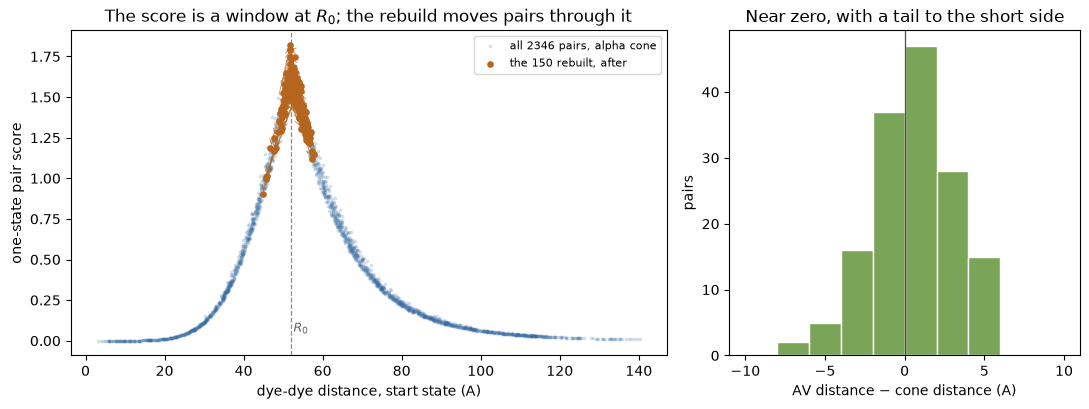

In [8]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4.2),
                             gridspec_kw={"width_ratios": [1.7, 1.0]})

ax.scatter([p.distance for p in cone], [p.value for p in cone], s=3, alpha=0.15,
           color="#3b6ea5", label=f"all {len(cone)} pairs, alpha cone")
for p in av_rows:
    k = key(p)
    ax.annotate("", xy=(p.distance, p.value), xytext=(cone_distance[k], cone_value[k]),
                arrowprops=dict(arrowstyle="->", color="#b5651d", lw=0.6, alpha=0.7))
ax.scatter([p.distance for p in av_rows], [p.value for p in av_rows], s=14,
           color="#b5651d", zorder=3, label=f"the {len(av_rows)} rebuilt, after")
ax.axvline(ws.R0, color="0.55", lw=0.9, ls="--")
ax.text(ws.R0 + 0.6, 0.05, "$R_0$", color="0.4", fontsize=9)
ax.set_xlabel("dye-dye distance, start state (A)")
ax.set_ylabel("one-state pair score")
ax.set_title("The score is a window at $R_0$; the rebuild moves pairs through it")
ax.legend(fontsize=8, loc="upper right")

edge = int(np.ceil(max(abs(shift.min()), abs(shift.max())) / 2.0) * 2) + 2
bx.hist(shift, bins=np.arange(-edge, edge + 2, 2), color="#7aa457", edgecolor="white")
bx.axvline(0, color="0.3", lw=0.9)
bx.set_xlabel("AV distance $-$ cone distance (A)")
bx.set_ylabel("pairs")
bx.set_title("Near zero, with a tail to the short side")
fig.tight_layout()
plt.show()

## Two states: which pair reports on the transition?

This is the question the workshop is actually about. hGBP1's two frames differ
by the swing of the helical stalk, and a pair is informative when the efficiency
it reports is *different* in the two.

`labelizer_pair_scores_two_states` takes both structures and both score tables,
matches positions by chain and residue number, and scores each pair by
$\text{jls}\cdot|E_1 - E_2|$. Only positions present above the threshold in both
states survive, which is why the list is shorter than the one-state one.

In [9]:
t0 = time.time()
with quiet():
    two_cone = list(bff.labelizer_pair_scores_two_states(
        paths["start"], paths["end"], label_scores["start"], label_scores["end"],
        fret_options()))
n_sites = int(round((1 + (1 + 8 * len(two_cone)) ** 0.5) / 2))
print(f"{len(two_cone)} pairs from {n_sites} sites present in both states, "
      f"in {time.time() - t0:.1f} s")

print(f"\n{'pair':<14} {'score':>7} {'jls':>6} {'d start':>9} {'d end':>8} {'dE':>7}")
for p in two_cone[:10]:
    de = ws.efficiency(p.distance_2) - ws.efficiency(p.distance)
    print(f"{name(p):<14} {p.value:7.4f} {p.joined_label_score:6.3f} {p.distance:9.1f} "
          f"{p.distance_2:8.1f} {de:+7.3f}")

p = two_cone[0]
change = abs(ws.efficiency(p.distance) - ws.efficiency(p.distance_2))
print(f"\njls * |E1 - E2| = {p.joined_label_score:.4f} * {change:.4f} = "
      f"{p.joined_label_score * change:.4f}   reported {p.value:.4f}")

1378 pairs from 53 sites present in both states, in 0.0 s

pair             score    jls   d start    d end      dE
B199-B564       3.0623  3.403      26.8     77.8  -0.900
B199-B568       3.0148  3.518      35.8     86.0  -0.857
B181-B568       2.9865  3.212      21.7     81.1  -0.930
B199-B569       2.9360  3.251      32.7     88.8  -0.903
B197-B568       2.9145  3.076      22.9     86.5  -0.948
B199-B567       2.8850  3.349      34.2     81.4  -0.862
B179-B568       2.8337  3.005      15.5     83.2  -0.943
B181-B567       2.7598  3.057      22.9     76.5  -0.903
B181-B569       2.7416  2.968      28.8     85.4  -0.924
B197-B564       2.7301  2.975      14.5     77.8  -0.918

jls * |E1 - E2| = 3.4030 * 0.8999 = 3.0623   reported 3.0623


### The joined label score is squared here

Note the `jls` column: it runs above 3, where no single-state pair reached 2.
The published arithmetic raises the *product* of the label scores to the
power one half whatever the count, and a two-state pair has four of them --
both sites in both states. For four scores near 1.8 that is $1.8^2$, not 1.8.

So the one-state and the two-state scores are **not on a common scale**, and a
number from one list cannot be compared with a number from the other.
`LABELIZER_MODEL_CORRECTED` uses the exponent $1/N$ instead, which is the line
the reference has commented out immediately below the one it runs.

In [10]:
p = two_cone[0]
parts = [label_scores["start"][f"{p.asym_id_1}{p.seq_id_1}"],
         label_scores["start"][f"{p.asym_id_2}{p.seq_id_2}"],
         label_scores["end"][f"{p.asym_id_1}{p.seq_id_1}"],
         label_scores["end"][f"{p.asym_id_2}{p.seq_id_2}"]]
print(f"{name(p)}: label scores {', '.join(f'{v:.3f}' for v in parts)}")
print(f"  published  prod^(1/2)   = {np.prod(parts) ** 0.5:.4f}   (reported "
      f"{p.joined_label_score:.4f})")
print(f"  corrected  prod^(1/4)   = {np.prod(parts) ** 0.25:.4f}")
print(f"\nlargest jls in the one-state list: "
      f"{max(q.joined_label_score for q in cone):.3f}")
print(f"largest jls in the two-state list: "
      f"{max(q.joined_label_score for q in two_cone):.3f}")

B199-B564: label scores 1.969, 1.728, 1.969, 1.728
  published  prod^(1/2)   = 3.4030   (reported 3.4030)
  corrected  prod^(1/4)   = 1.8447

largest jls in the one-state list: 1.969
largest jls in the two-state list: 3.681


### There is no refinement tier here

`labelizer_fret_pair_scores` screens with the cone and rebuilds the best few
with volumes. `labelizer_pair_scores_two_states` does not: it places every site
once with `probe_model` and stops. Setting `n_refine` on it changes nothing,
and the cell below shows that rather than asserting it.

That is not a gap that has to be worked around, because the cost of an
accessible-volume screen is linear in *sites*, not in pairs -- each site's cloud
is built once and reused for every pair it appears in. With 53 sites in two
states it is 106 volumes, ten seconds, and then the whole list is
exact.

In [11]:
with quiet():
    attempted = list(bff.labelizer_pair_scores_two_states(
        paths["start"], paths["end"], label_scores["start"], label_scores["end"],
        fret_options(n_refine=150)))
print("any row rebuilt with a volume:",
      any(p.probe_model == bff.PROBE_MODEL_ACCESSIBLE_VOLUME for p in attempted))
print("order identical to n_refine = 0:",
      [key(p) for p in attempted] == [key(p) for p in two_cone])

any row rebuilt with a volume: False
order identical to n_refine = 0: True


In [12]:
t0 = time.time()
with quiet():
    two_av = list(bff.labelizer_pair_scores_two_states(
        paths["start"], paths["end"], label_scores["start"], label_scores["end"],
        fret_options(probe_model=bff.PROBE_MODEL_ACCESSIBLE_VOLUME)))
print(f"{len(two_av)} pairs, every one with real dye clouds, in {time.time() - t0:.0f} s")

two_cone_by_key = {key(p): p for p in two_cone}
two_cone_rank = {key(p): i for i, p in enumerate(two_cone)}

print(f"\n{'pair':<14} {'score':>7} {'start':>7} {'end':>7} {'change':>7} "
      f"{'E start':>9} {'E end':>7} {'cone rank':>10}")
for p in two_av[:12]:
    print(f"{name(p):<14} {p.value:7.4f} {p.distance:7.1f} {p.distance_2:7.1f} "
          f"{p.distance_2 - p.distance:+7.1f} {ws.efficiency(p.distance):9.3f} "
          f"{ws.efficiency(p.distance_2):7.3f} {two_cone_rank[key(p)] + 1:>10}")

1378 pairs, every one with real dye clouds, in 9 s

pair             score   start     end  change   E start   E end  cone rank
B197-B568       2.7398    31.2    81.2   +50.0     0.955   0.064          5
B199-B569       2.7280    36.6    84.0   +47.5     0.892   0.053          4
B181-B568       2.7198    33.0    76.2   +43.2     0.939   0.092          3
B199-B568       2.7036    39.4    79.5   +40.1     0.841   0.073          2
B179-B568       2.6758    28.3    77.4   +49.1     0.975   0.084          7
B199-B564       2.6339    33.2    68.3   +35.1     0.937   0.163          1
B197-B569       2.6163    29.7    86.1   +56.5     0.967   0.046         11
B199-B567       2.4953    38.2    72.5   +34.4     0.865   0.120          6
B197-B564       2.4784    26.7    69.5   +42.8     0.982   0.149         10
B197-B567       2.4740    31.3    73.7   +42.4     0.955   0.110         12
B199-B557       2.4284    25.0    66.3   +41.2     0.988   0.189         13
B181-B567       2.4233    33.9    70

The cone and the volumes disagree here too, and this time the disagreement has
a shape: the cone is **short** where the sites are close together and **long**
where they are far apart. Both follow from replacing a cloud by a point. Two
nearby clouds have parts of themselves much further apart than their centres
are, and the efficiency-weighted average feels them; two distant clouds are
pulled together by the same $1/R^6$ weighting, which favours whichever corners
of the two clouds happen to be nearest. The next cell puts numbers on it.

The top twelve is not twelve independent experiments. Every one of them pairs a
residue of the C-terminal tail (557-569) against a residue of the stalk
(179-199), because the tail and the stalk are what the trajectory moves apart:
`B179-B568`, `B197-B568`, `B199-B569` and `B199-B568` are four readings of one
motion, and choosing all four would buy almost nothing over choosing one.
Reading a two-state list means grouping it by what moves before ranking it.

In [13]:
d1_cone = np.array([two_cone_by_key[key(p)].distance for p in two_av])
d1_av = np.array([p.distance for p in two_av])
d2_cone = np.array([two_cone_by_key[key(p)].distance_2 for p in two_av])
d2_av = np.array([p.distance_2 for p in two_av])

print(f"{'cone distance':>16} {'pairs':>7} {'AV - cone':>11}")
for lo, hi in ((0, 30), (30, 45), (45, 60), (60, 999)):
    inside = (d1_cone >= lo) & (d1_cone < hi)
    if inside.sum():
        label = f"{lo}-{hi} A" if hi < 999 else f"over {lo} A"
        print(f"{label:>16} {inside.sum():>7} {(d1_av - d1_cone)[inside].mean():>+10.1f} A")
print(f"\nboth states pooled: mean {np.concatenate([d1_av - d1_cone, d2_av - d2_cone]).mean():+.2f} A, "
      f"median {np.median(np.concatenate([d1_av - d1_cone, d2_av - d2_cone])):+.2f} A")

print(f"\nthe cone's best pair {name(two_cone[0])} is the volumes' number "
      f"{[key(q) for q in two_av].index(key(two_cone[0])) + 1}; "
      f"the volumes' best pair {name(two_av[0])} was the cone's number "
      f"{two_cone_rank[key(two_av[0])] + 1}")

   cone distance   pairs   AV - cone
          0-30 A     170      +11.0 A
         30-45 A     251       +3.9 A
         45-60 A     270       +0.1 A
       over 60 A     687       -3.4 A

both states pooled: mean +0.29 A, median -0.49 A

the cone's best pair B199-B564 is the volumes' number 6; the volumes' best pair B197-B568 was the cone's number 5


## The one-state and two-state answers are different questions

They barely share an answer. The one-state screen looks for pairs sitting at
$R_0$ in the start structure; the two-state screen looks for pairs whose
efficiency moves. A pair that sits exactly at $R_0$ in both states is perfect
by the first and worthless by the second.

On hGBP1 the two lists share nothing at all, and for two different reasons at
the two ends. The one-state winners sit at $R_0$ in the start structure on
sites that do not stay labelable: `B270` falls from 1.70 to 1.04 across the
transition and `B374` to 1.28, so two of the five are never even formed by the
two-state screen and the other three land 138th and 164th of 1378. The
two-state winners are pairs that go from under 40 A to 68-86 A, which is
nowhere near $R_0$ in either state, so the one-state screen puts them at the
bottom of its own list.

In [14]:
single_rank = {key(p): i for i, p in enumerate(refined)}
two_rank = {key(p): i for i, p in enumerate(two_av)}
overlap = set(key(p) for p in refined[:50]) & set(key(p) for p in two_av[:50])
print(f"pairs in both top-50 lists: {len(overlap)}  {sorted('%s%d-%s%d' % k for k in overlap)}")

print(f"\n{'the one-state winners':<24} {'in the two-state list':>22}")
for p in refined[:5]:
    k = key(p)
    if k in two_rank:
        where = f"rank {two_rank[k] + 1} of {len(two_av)}"
    else:
        below = [f"{c}{r} scores {by_site['end'][f'{c}{r}']:.2f} at the end"
                 for c, r in ((p.asym_id_1, p.seq_id_1), (p.asym_id_2, p.seq_id_2))
                 if by_site["end"].get(f"{c}{r}", 0.0) < THRESHOLD]
        where = "never paired: " + ", ".join(below)
    print(f"{name(p):<14} {p.value:7.4f}   {where}")

print(f"\n{'the two-state winners':<24} {'in the one-state list':>22}")
for p in two_av[:5]:
    k = key(p)
    where = f"rank {single_rank[k] + 1} of {len(refined)}" if k in single_rank else "not scored"
    print(f"{name(p):<14} {p.value:7.4f}   {where}")

pairs in both top-50 lists: 0  []

the one-state winners     in the two-state list
B374-B457       1.8200   never paired: B374 scores 1.28 at the end
A151-B199       1.7958   rank 138 of 1378
B199-B270       1.7910   never paired: B270 scores 1.04 at the end
A12-B270        1.7497   never paired: B270 scores 1.04 at the end
A81-B568        1.7447   rank 164 of 1378

the two-state winners     in the one-state list
B197-B568       2.7398   rank 2114 of 2346
B199-B569       2.7280   rank 1431 of 2346
B181-B568       2.7198   rank 2153 of 2346
B199-B568       2.7036   rank 1147 of 2346
B179-B568       2.6758   rank 2266 of 2346


## Before believing any of it: does the dye fit?

One thing the screen does quietly. When a site's accessible volume comes back
empty -- no voxel the dye can reach -- the pair distance falls back to the
distance between the two attachment points, and the row is still scored and
still ranked. Nothing in the returned row says so.

So the list has to be audited: rebuild the volumes of every site it uses, with
the screen's own parameters, and count the points. There are only 53 sites, so
auditing all of them costs less than auditing the top twenty would have cost on
a bigger protein.

In [15]:
def screen_volume(state, chain, resi, options):
    # The site's cloud with exactly the parameters the pair screen used.
    return bff.get_av_from_pdb(paths[state], chain, resi, "CB", options.linker_length,
                               options.linker_width, options.r1, options.r2, options.r3,
                               options.grid_resolution, -1.0, 0)


audit_sites = sorted({site for p in two_av
                      for site in ((p.asym_id_1, p.seq_id_1), (p.asym_id_2, p.seq_id_2))})
options = fret_options()
points = {}
t0 = time.time()
with quiet():
    for chain, resi in audit_sites:
        for state in ("start", "end"):
            points[(state, chain, resi)] = screen_volume(state, chain, resi, options).get_n_points()
print(f"{len(audit_sites)} sites x 2 states rebuilt in {time.time() - t0:.1f} s\n")

THIN = 500
empty = [s for s in audit_sites if min(points[("start", *s)], points[("end", *s)]) == 0]
thin = [s for s in audit_sites
        if 0 < min(points[("start", *s)], points[("end", *s)]) < THIN]
print(f"{'site':>6} {'points start':>13} {'points end':>11} {'label score':>12}")
for chain, resi in empty + thin:
    a, b = points[("start", chain, resi)], points[("end", chain, resi)]
    flag = "  <- empty" if min(a, b) == 0 else "  <- thin"
    print(f"{chain}{resi:<5} {a:>13} {b:>11} "
          f"{by_site['start'][f'{chain}{resi}']:>12.2f}{flag}")
print(f"\n{len(audit_sites) - len(empty) - len(thin)} of the {len(audit_sites)} sites "
      f"have a healthy cloud in both states")

53 sites x 2 states rebuilt in 0.3 s

  site  points start  points end  label score
B383            1628         309         1.97  <- thin

52 of the 53 sites have a healthy cloud in both states


In [16]:
def usable(p):
    sites = ((p.asym_id_1, p.seq_id_1), (p.asym_id_2, p.seq_id_2))
    return all(points.get((state, chain, resi), 1) > 0
               for state in ("start", "end") for chain, resi in sites)


rejected = [(i, p) for i, p in enumerate(two_av) if not usable(p)]
if rejected:
    print(f"{len(rejected)} of the {len(two_av)} pairs rest on a site with no accessible "
          f"volume at all; the best of them is ranked {rejected[0][0] + 1}:")
    for i, p in rejected[:4]:
        broken = [f"{chain}{resi}" for chain, resi in ((p.asym_id_1, p.seq_id_1),
                                                       (p.asym_id_2, p.seq_id_2))
                  if min(points[("start", chain, resi)], points[("end", chain, resi)]) == 0]
        print(f"   rank {i + 1:>4}  {name(p):<14} {', '.join(broken)} has no volume, and the "
              f"row still reports {p.distance:.1f} -> {p.distance_2:.1f} A")
else:
    print(f"none of the {len(two_av)} pairs rests on a dead site this time: every site "
          "the list uses has a cloud in both states")

shortlist = [p for p in two_av[:12] if usable(p)]
print(f"\nshortlist after the audit: {', '.join(name(p) for p in shortlist)}")

none of the 1378 pairs rests on a dead site this time: every site the list uses has a cloud in both states

shortlist after the audit: B197-B568, B199-B569, B181-B568, B199-B568, B179-B568, B199-B564, B197-B569, B199-B567, B197-B564, B197-B567, B199-B557, B181-B567


This time the audit comes back clean: no site the two-state list uses is dead,
and exactly one is thin. That is a fact about this structure and this
threshold, not a guarantee the screen has earned. A site whose accessible
volume comes back empty is still scored and still ranked, on the strength of
its label score alone, exactly as if its dye had somewhere to go -- the label
score is about whether a cysteine belongs there, and it says nothing about
whether a dye on a 20 A linker has anywhere to go once it is attached. Those
are two different questions and the screen only asks the first one before it
starts pairing.

The one thin site is `B383`, and it is not a marginal member of the list but
its third-best site by label score, 1.97, with 1628 grid points at the start
of the transition and 309 at the end. Thin in one state only is the worse
failure, because a pair using it looks like a pair whose distance changes. It
is not empty, so nothing rejects it, but a cloud that small is a dye wedged
into a pocket, and its mean distance is whatever that pocket allows. Watch
what happens to it below.

## An independent check: our own volumes, the real two dyes

The screen used one symmetric dye at both ends, because that is what its
options can express. A real experiment has a donor and an acceptor with
different linkers -- Alexa488 on 20 A, Alexa647 on 22 A -- and `workshop.av`
builds each with its own geometry and a 5 A clearance around the attachment
point, which the screen does not use.

So this is a genuinely separate calculation of the same quantity. If the pair
score means what it claims, its ranking should survive it.

In [17]:
volumes = {}


def volume(state, chain, resi, dye):
    entry = (state, chain, resi, dye)
    if entry not in volumes:
        with quiet():
            volumes[entry] = ws.av(paths[state], chain, resi, dye)
    return volumes[entry]


controls = [two_av[200], two_av[1000], two_av[-1]]
probes = [(p, False) for p in shortlist] + [(p, True) for p in controls]
checked = []
t0 = time.time()
print(f"{'pair':<14} {'score':>7} | {'R start':>9} {'R end':>7} {'change':>7} | "
      f"{'E start':>9} {'E end':>7} {'|dE|':>6}")
for p, is_control in probes:
    try:
        distance = {}
        for state in ("start", "end"):
            donor = volume(state, p.asym_id_1, p.seq_id_1, "Alexa488")
            acceptor = volume(state, p.asym_id_2, p.seq_id_2, "Alexa647")
            distance[state] = ws.rda_e(donor, acceptor)
    except ws.EmptyVolume as problem:
        print(f"{name(p):<14} {p.value:7.4f} | no volume: {problem}")
        continue
    ec, eo = ws.efficiency(distance["start"]), ws.efficiency(distance["end"])
    checked.append((p, distance["start"], distance["end"], ec, eo))
    mark = "   (control)" if is_control else ""
    print(f"{name(p):<14} {p.value:7.4f} | {distance['start']:9.1f} {distance['end']:7.1f} "
          f"{distance['end'] - distance['start']:+7.1f} | {ec:9.3f} {eo:7.3f} "
          f"{abs(eo - ec):6.3f}{mark}")
print(f"\n{len(volumes)} volumes built in {time.time() - t0:.1f} s")

pair             score |   R start   R end  change |   E start   E end   |dE|
B197-B568       2.7398 |      33.1    79.8   +46.7 |     0.938   0.071  0.867
B199-B569       2.7280 |      38.0    80.6   +42.6 |     0.867   0.067  0.800
B181-B568       2.7198 |      34.7    75.1   +40.5 |     0.919   0.099  0.820
B199-B568       2.7036 |      39.8    77.8   +38.0 |     0.833   0.082  0.751
B179-B568       2.6758 |      30.9    76.2   +45.3 |     0.958   0.092  0.866
B199-B564       2.6339 |      33.7    67.7   +34.0 |     0.931   0.170  0.761
B197-B569       2.6163 |      32.2    82.8   +50.5 |     0.946   0.058  0.888
B199-B567       2.4953 |      38.9    72.4   +33.5 |     0.852   0.121  0.731
B197-B564       2.4784 |      28.4    69.2   +40.8 |     0.974   0.153  0.822
B197-B567       2.4740 |      33.0    74.0   +41.1 |     0.939   0.107  0.832
B199-B557       2.4284 |      27.7    63.8   +36.1 |     0.978   0.226  0.752
B181-B567       2.4233 |      35.9    70.7   +34.8 |     0.902  

In [18]:
score = np.array([p.value for p, *_ in checked])
change = np.array([abs(eo - ec) for _, _, _, ec, eo in checked])
jls = np.array([p.joined_label_score for p, *_ in checked])

screen_change = np.array([abs(ws.efficiency(p.distance) - ws.efficiency(p.distance_2))
                          for p, *_ in checked])
print(f"pair score against the independent |dE|:  r = {np.corrcoef(score, change)[0, 1]:+.3f}")
print(f"screen |dE| against the independent |dE|: r = "
      f"{np.corrcoef(screen_change, change)[0, 1]:+.3f}")
print(f"jls x independent |dE| against the score: r = "
      f"{np.corrcoef(jls * change, score)[0, 1]:+.3f}")

by_score = [name(checked[i][0]) for i in np.argsort(-score)]
by_change = [name(checked[i][0]) for i in np.argsort(-change)]
print(f"\nranked by pair score:       {', '.join(by_score[:6])}")
print(f"ranked by independent |dE|: {', '.join(by_change[:6])}")

def thinnest(p):
    return min(points.get((state, chain, resi), 10 ** 6)
               for state in ("start", "end")
               for chain, resi in ((p.asym_id_1, p.seq_id_1), (p.asym_id_2, p.seq_id_2)))


print(f"\n{'pair':<14} {'|dE| screen':>12} {'|dE| check':>11} {'difference':>11}")
for row, (p, *_rest) in enumerate(checked):
    flag = "   <- thin volume" if thinnest(p) < THIN else ""
    print(f"{name(p):<14} {screen_change[row]:>12.3f} {change[row]:>11.3f} "
          f"{change[row] - screen_change[row]:>+11.3f}{flag}")

print(f"\nthe flagged sites, in grid points: the screen's cloud against this check's")
for p, *_rest in checked:
    if thinnest(p) >= THIN:
        continue
    for dye, (chain, resi) in (("Alexa488", (p.asym_id_1, p.seq_id_1)),
                               ("Alexa647", (p.asym_id_2, p.seq_id_2))):
        for state in ("start", "end"):
            mine = len(ws.av_points(volume(state, chain, resi, dye)))
            print(f"   {chain}{resi:<4} {state:<6} screen {points[(state, chain, resi)]:>5}"
                  f"   this check ({dye}, 5 A clearance) {mine:>5}")

pair score against the independent |dE|:  r = +0.987
screen |dE| against the independent |dE|: r = +0.999
jls x independent |dE| against the score: r = +0.999

ranked by pair score:       B197-B568, B199-B569, B181-B568, B199-B568, B179-B568, B199-B564
ranked by independent |dE|: B197-B569, B197-B568, B179-B568, B197-B567, B197-B564, B181-B568

pair            |dE| screen  |dE| check  difference
B197-B568             0.891       0.867      -0.024
B199-B569             0.839       0.800      -0.039
B181-B568             0.847       0.820      -0.026
B199-B568             0.769       0.751      -0.017
B179-B568             0.890       0.866      -0.024
B199-B564             0.774       0.761      -0.013
B197-B569             0.921       0.888      -0.032
B199-B567             0.745       0.731      -0.014
B197-B564             0.833       0.822      -0.011
B197-B567             0.845       0.832      -0.013
B199-B557             0.798       0.752      -0.047
B181-B567             0.793  

The screen's ranking survives the cross-check, in outline and very nearly in
detail. Every shortlisted pair moves a long way between the two states
under a completely separate calculation -- the screen is not inventing the
transition -- the controls taken from far down the list move by 0.34, 0.00 and
0.00, and the two calculations of $|\Delta E|$ agree to within 0.05 on every
row, including the thin site the audit flagged. `B383`'s 309-voxel cloud at the
end of the transition grows to 843 under the 5 A clearance of `workshop.av`,
and the efficiency barely notices, because the pair that uses it sits near
90 A at both ends, far enough from $R_0$ that a few Angstrom there does not
move $E$.

The order inside the shortlist is still not reproduced, and for a reason that
is arithmetic rather than geometry: the score is not $|\Delta E|$, it is
$\text{jls}\cdot|\Delta E|$. The pair with the largest efficiency change of
the twelve, `B197-B569`, is seventh by score, because `B197` and `B569` are two
of the less labelable sites the shortlist uses -- 1.72 and 1.65, against
`B199`'s 1.97.

There is a bigger objection to this shortlist than its order, and neither score
raises it. Every one of these pairs runs from an efficiency above 0.8 to one
below 0.25. A $|\Delta E|$ near 0.9 sounds decisive, but both ends of it sit
where the efficiency is flat in distance -- at $E = 0.95$ a 5 A error is
invisible and at $E = 0.08$ it is worse. What a real experiment wants is a pair
that crosses $R_0$ rather than a pair that runs the whole range, and the
one-state score is exactly the term that would have said so. The two screens
disagreeing, on this molecule, is the two of them each being half right.

The practical reading: take the top ten or fifteen of a two-state screen as a
*set* of candidates, group it by which motion each pair reports, and settle the
order with the dyes you are actually going to use and an eye on where $R_0$
falls.

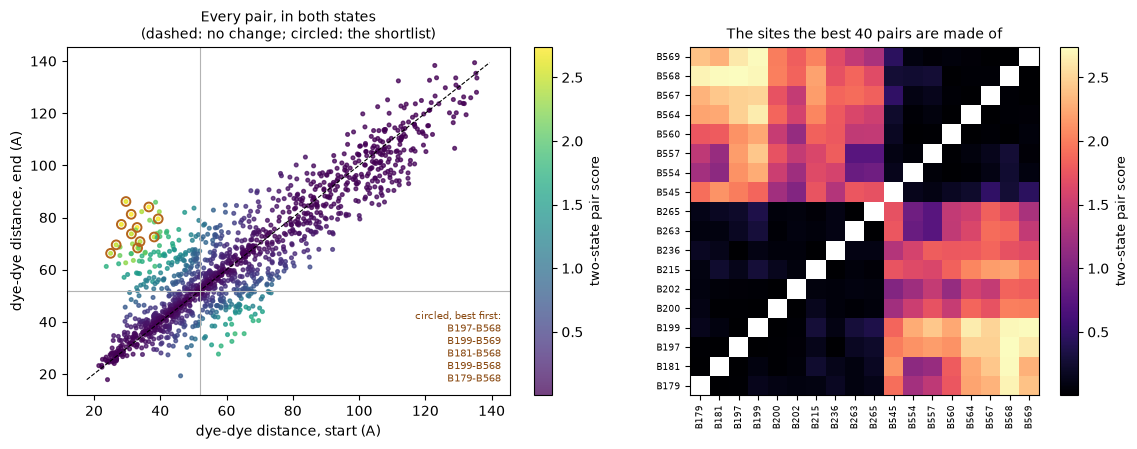

In [19]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11.5, 4.6),
                             gridspec_kw={"width_ratios": [1.15, 1.0]})

colours = ax.scatter(d1_av, d2_av, c=[p.value for p in two_av], s=7, cmap="viridis",
                     alpha=0.75)
fig.colorbar(colours, ax=ax, fraction=0.046).set_label("two-state pair score", fontsize=9)
span = [min(d1_av.min(), d2_av.min()), max(d1_av.max(), d2_av.max())]
ax.plot(span, span, "k--", lw=0.8)
ax.axvline(ws.R0, color="0.7", lw=0.8); ax.axhline(ws.R0, color="0.7", lw=0.8)
ax.text(0.98, 0.03, "circled, best first:\n" + "\n".join(name(p) for p in shortlist[:5]),
        transform=ax.transAxes, ha="right", va="bottom", fontsize=7.5, color="#8a4a12")
ax.scatter([p.distance for p in shortlist], [p.distance_2 for p in shortlist],
           s=40, facecolor="none", edgecolor="#b5651d", lw=1.4)
ax.set_xlabel("dye-dye distance, start (A)")
ax.set_ylabel("dye-dye distance, end (A)")
ax.set_title("Every pair, in both states\n(dashed: no change; circled: the shortlist)",
             fontsize=10)

# the same numbers as a site-by-site matrix, over the sites the best pairs use
matrix_sites = sorted({s for p in two_av[:40]
                       for s in ((p.asym_id_1, p.seq_id_1), (p.asym_id_2, p.seq_id_2))})
index = {site: i for i, site in enumerate(matrix_sites)}
grid = np.full((len(matrix_sites), len(matrix_sites)), np.nan)
for p in two_av:
    a = (p.asym_id_1, p.seq_id_1); b = (p.asym_id_2, p.seq_id_2)
    if a in index and b in index:
        grid[index[a], index[b]] = grid[index[b], index[a]] = p.value
image = bx.imshow(grid, cmap="magma", origin="lower")
fig.colorbar(image, ax=bx, fraction=0.046).set_label("two-state pair score", fontsize=9)
ticks = range(len(matrix_sites))
bx.set_xticks(ticks, [f"{c}{r}" for c, r in matrix_sites], rotation=90, fontsize=6.5)
bx.set_yticks(ticks, [f"{c}{r}" for c, r in matrix_sites], fontsize=6.5)
bx.set_title("The sites the best 40 pairs are made of", fontsize=10)
fig.tight_layout()
plt.show()

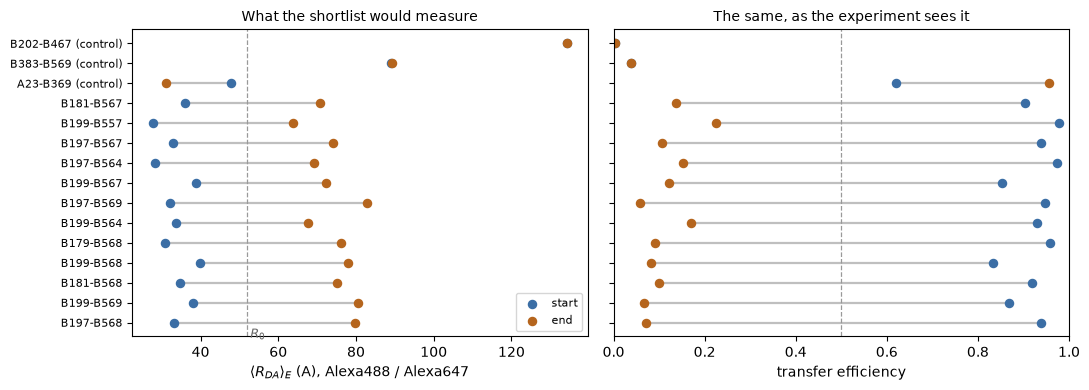

In [20]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
labels = [name(p) + (" (control)" if any(p is c for c in controls) else "")
          for p, *_ in checked]
y = np.arange(len(checked))

for row, (_p, rc, ro, ec, eo) in enumerate(checked):
    ax.plot([rc, ro], [row, row], color="0.75", lw=1.6, zorder=1)
    bx.plot([ec, eo], [row, row], color="0.75", lw=1.6, zorder=1)
ax.scatter([r[1] for r in checked], y, s=34, color="#3b6ea5", zorder=2, label="start")
ax.scatter([r[2] for r in checked], y, s=34, color="#b5651d", zorder=2, label="end")
bx.scatter([r[3] for r in checked], y, s=34, color="#3b6ea5", zorder=2)
bx.scatter([r[4] for r in checked], y, s=34, color="#b5651d", zorder=2)

ax.axvline(ws.R0, color="0.6", lw=0.9, ls="--")
ax.text(ws.R0 + 0.8, -0.8, "$R_0$", color="0.4", fontsize=9)
ax.set_yticks(y, labels, fontsize=8)
ax.set_xlabel(r"$\langle R_{DA}\rangle_E$ (A), Alexa488 / Alexa647")
ax.set_title("What the shortlist would measure", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
bx.axvline(0.5, color="0.6", lw=0.9, ls="--")
bx.set_xlim(0, 1)
bx.set_xlabel("transfer efficiency")
bx.set_title("The same, as the experiment sees it", fontsize=10)
fig.tight_layout()
plt.show()

## The winner, on both structures

The best pair that survives the audit, drawn as the two dye clouds it would
actually put on the protein -- donor in green, acceptor in red -- at the two
ends of the transition. The volumes are `workshop.av`, the same call the table
above used, so the picture and the numbers cannot drift apart.

If the panels stay blank, Mol* needs internet access from the browser; nothing
else in the notebook depends on it.

In [21]:
winner = shortlist[0]
print(f"{name(winner)}: score {winner.value:.4f}, "
      f"{winner.distance:.1f} A at the start -> {winner.distance_2:.1f} A at the end (screen)")
row = next(r for r in checked if r[0] is winner)
print(f"{'':>{len(name(winner))}}  independent check: {row[1]:.1f} -> {row[2]:.1f} A, "
      f"E {row[3]:.3f} -> {row[4]:.3f}")

panels = []
with quiet():
    for state in ("start", "end"):
        panels.append(ws.site_panel(
            state,
            [{"chain": winner.asym_id_1, "resi": winner.seq_id_1, "dye": "Alexa488",
              "colour": ws.DONOR_COLOUR},
             {"chain": winner.asym_id_2, "resi": winner.seq_id_2, "dye": "Alexa647",
              "colour": ws.ACCEPTOR_COLOUR}],
            title=f"hGBP1 frame {ENDS[state]} - {name(winner)}",
            pdb_path=paths[state]))
ws.show(panels)

B197-B568: score 2.7398, 31.2 A at the start -> 81.2 A at the end (screen)
           independent check: 33.1 -> 79.8 A, E 0.938 -> 0.071


## One file out

The scores, the pairs and the settings that produced them go into one
`.mmfdb.pto` container rather than a folder of CSVs. It holds the structure
verbatim -- so the coordinates that were scored can be recovered and checked
against a hash, not merely referred to by file name -- the score rows with
their columns named by MMFDB dictionary items, the pair rows, and the complete
settings, model included.

That matters because every number above depends on settings that are easy to
lose: which terms were in the model, the threshold, the probe radius, $R_0$,
which dye model placed the distance, and -- here -- which two frames of a
58-frame trajectory were called the two states. Six CSVs record the numbers and
forget the question. The container is written into a scratch directory, because
an example that writes into the source tree leaves derived files behind that
look like inputs next time.

In [22]:
work = tempfile.mkdtemp()
out = os.path.join(work, f"hGBP1_frame{ENDS['start']}_frame{ENDS['end']}.mmfdb.pto")
settings = bff.labelizer_settings_json(model, bff.LabelizerOptions(),
                                       fret_options(probe_model=bff.PROBE_MODEL_ACCESSIBLE_VOLUME),
                                       "")
with quiet():
    bff.labelizer_write_pto(out, paths["start"], rows["start"], two_av[:500], settings)
print(f"{os.path.basename(out)}  {os.path.getsize(out) / 1048576.0:.2f} MB")

with quiet():
    back_scores = bff.labelizer_read_pto_scores(out)
    back_pairs = bff.labelizer_read_pto_pairs(out)
    digest = bff.labelizer_extract_pto_structure(out, os.path.join(work, "recovered.pdb"))
print(f"read back: {len(back_scores)} score rows, {len(back_pairs)} pair rows")
print(f"recovered structure sha256 {digest[:16]}...")
print(f"settings carried: {len(bff.labelizer_read_pto_settings(out))} characters of JSON")

hGBP1_frame0_frame57.mmfdb.pto  1.96 MB
read back: 3990 score rows, 500 pair rows
recovered structure sha256 4748375181215bd6...
settings carried: 944 characters of JSON


## What to carry forward

* The one-state and the two-state pair scores answer different questions and,
  on hGBP1, agree on nothing whatsoever: zero pairs in common between the two
  top fifties. Pick the one that matches the experiment before reading any
  ranking -- and if the answer is "both", say so, because a pair that both
  screens like is a pair that crosses $R_0$ while it moves.
* The alpha cone is a screen, not an answer. Its median error here is under an
  Angstrom and its tail is 7.6, which is the failure mode that hurts a ranking
  most: 48 of the 150 rebuilt pairs leave the top 150, and the cone's
  number 108 became the rebuild's number 1.
* `labelizer_pair_scores_two_states` has no refinement tier, so give it
  `probe_model = PROBE_MODEL_ACCESSIBLE_VOLUME` directly: the cost is linear in
  sites, and ten seconds buys an exact list of all 1378 pairs.
* A site whose dye has nowhere to go is still scored and still ranked. None of
  this run's 53 sites is dead and one is thin in one state -- luck, not a
  guarantee. Audit every site the list uses; here it cost a third of a second.
* Treat the top of a two-state list as a set of candidates, and group it by
  which motion each pair reports before counting how many you have.

Notebook 3 takes one of these pairs apart: what an accessible volume is, how the
distance is averaged out of it, and where the rotamer libraries come in.